# SailBoard Testing
Interactive notebook for testing weather, tide, and display components.

In [1]:
import sys
sys.path.insert(0, 'src')

from datetime import datetime, timedelta
import config

print(f"Location: {config.LATITUDE}, {config.LONGITUDE}")
print(f"Tide Station: {config.TIDE_STATION_ID}")

Location: 42.36, -71.04
Tide Station: 8443838


## Tides Client

In [2]:
from clients import NoaaTidesClient

tides = NoaaTidesClient(config.TIDE_STATION_ID)
start = datetime.now()
end = start + timedelta(days=2)

tides_df = tides.fetch(start, end)
tides_df

,tide_height_m,tide_type
time,,
2026-03-07 00:17:00,0.060,low
2026-03-07 06:27:00,3.030,high
2026-03-07 12:42:00,-0.003,low
2026-03-07 18:54:00,2.836,high
2026-03-08 00:57:00,0.205,low
2026-03-08 07:07:00,2.951,high
2026-03-08 13:26:00,0.117,low
2026-03-08 19:37:00,2.678,high
2026-03-09 01:39:00,0.357,low


## Weather Client

In [3]:
from clients import NoaaWeatherClient

weather = NoaaWeatherClient(config.LATITUDE, config.LONGITUDE)
start = datetime.now()
end = start + timedelta(days=3)

weather_df = weather.fetch(start, end)
weather_df

,period_name,is_daytime,temperature_f,wind_direction,short_forecast,period_end,wind_speed_avg_kts,wind_gust_max_kts
time,,,,,,,,
2026-03-08 06:00:00,Sunday,True,60,SW,Chance Rain Showers then Mostly Cloudy,2026-03-08 18:00:00,8.833333,16.0
2026-03-08 18:00:00,Sunday Night,False,40,SW,Mostly Clear,2026-03-09 06:00:00,7.333333,13.0
2026-03-09 06:00:00,Monday,True,65,SW,Sunny,2026-03-09 18:00:00,8.428571,19.0
2026-03-09 18:00:00,Monday Night,False,43,SW,Mostly Clear,2026-03-10 06:00:00,10.142857,20.0
2026-03-10 06:00:00,Tuesday,True,64,SW,Sunny,2026-03-10 18:00:00,6.0,12.0
2026-03-10 18:00:00,Tuesday Night,False,45,S,Partly Cloudy,2026-03-11 06:00:00,7.0,11.0


In [4]:
# Daytime only
weather_df[weather_df['is_daytime'] == True][['period_name', 'wind_speed_avg_kts', 'wind_gust_max_kts', 'wind_direction', 'short_forecast']]

,period_name,wind_speed_avg_kts,wind_gust_max_kts,wind_direction,short_forecast
time,,,,,
2026-03-08 06:00:00,Sunday,8.833333,16.0,SW,Chance Rain Showers then Mostly Cloudy
2026-03-09 06:00:00,Monday,8.428571,19.0,SW,Sunny
2026-03-10 06:00:00,Tuesday,6.0,12.0,SW,Sunny


## Unified SailingDataManager

In [5]:
from data_manager import SailingDataManager

manager = SailingDataManager()
df = manager.fetch(days=3)
df

,period_name,is_daytime,temperature_f,wind_direction,short_forecast,period_end,wind_speed_avg_kts,wind_gust_max_kts,next_tide_time,next_tide_type,next_tide_height_m
time,,,,,,,,,,,
2026-03-07 19:00:00,Tonight,False,45,SW,Cloudy then Slight Chance Rain Showers,2026-03-08 06:00:00,11.8,17.0,2026-03-08 00:57:00,low,0.205
2026-03-08 06:00:00,Sunday,True,60,SW,Chance Rain Showers then Mostly Cloudy,2026-03-08 18:00:00,8.833333,16.0,2026-03-08 07:07:00,high,2.951
2026-03-08 18:00:00,Sunday Night,False,40,SW,Mostly Clear,2026-03-09 06:00:00,7.333333,13.0,2026-03-08 19:37:00,high,2.678
2026-03-09 06:00:00,Monday,True,65,SW,Sunny,2026-03-09 18:00:00,8.428571,19.0,2026-03-09 07:49:00,high,2.852
2026-03-09 18:00:00,Monday Night,False,43,SW,Mostly Clear,2026-03-10 06:00:00,10.8,20.0,2026-03-09 20:24:00,high,2.522
2026-03-10 06:00:00,Tuesday,True,64,SW,Sunny,2026-03-10 18:00:00,None,None,2026-03-10 08:36:00,high,2.749
2026-03-10 18:00:00,Tuesday Night,False,45,S,Partly Cloudy,2026-03-11 06:00:00,None,None,2026-03-10 21:16:00,high,2.388


In [6]:
# Daytime forecast with tides
forecast = manager.get_daytime_forecast(num_days=3)
forecast

,period_name,is_daytime,temperature_f,wind_direction,short_forecast,period_end,wind_speed_avg_kts,wind_gust_max_kts,next_tide_time,next_tide_type,next_tide_height_m
time,,,,,,,,,,,
2026-03-08 06:00:00,Sunday,True,60,SW,Chance Rain Showers then Mostly Cloudy,2026-03-08 18:00:00,8.833333,16.0,2026-03-08 07:07:00,high,2.951
2026-03-09 06:00:00,Monday,True,65,SW,Sunny,2026-03-09 18:00:00,8.428571,19.0,2026-03-09 07:49:00,high,2.852
2026-03-10 06:00:00,Tuesday,True,64,SW,Sunny,2026-03-10 18:00:00,None,None,2026-03-10 08:36:00,high,2.749


In [7]:
# Next tides
manager.get_next_tides(4)

,tide_height_m,tide_type
time,,
2026-03-08 00:57:00,0.205,low
2026-03-08 07:07:00,2.951,high
2026-03-08 13:26:00,0.117,low
2026-03-08 19:37:00,2.678,high


## Display (MockDisplay + BoardLayout)

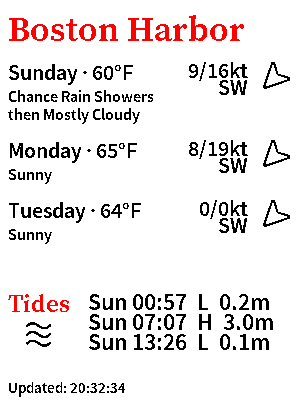

In [8]:
from display import MockDisplay, BoardLayout

display = MockDisplay(width=300, height=400)

forecast = manager.get_daytime_forecast(num_days=3)
tides    = manager.get_next_tides(3)

layout = BoardLayout(display)
layout.render(forecast, tides, datetime.now())

display.to_rgb()

In [9]:
display.save('test_output.png')
print(f'Saved to test_output.png ({display.width}x{display.height})')

Saved to test_output.png (300x400)
